In [1]:
#how to treat outliers
#trimming, capping, missing values, Discretization

#how todetect Outliers
#Normal Distribution (means a observation is out of mean +,- 3(standard devion) then its outlier)
#Skewed Distribution (means a obeservation is not between minimum and max obervation)
#Other observation (means it is outside of 2.5 percentile and 97.5 percentile)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('placement.csv')


In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [5]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


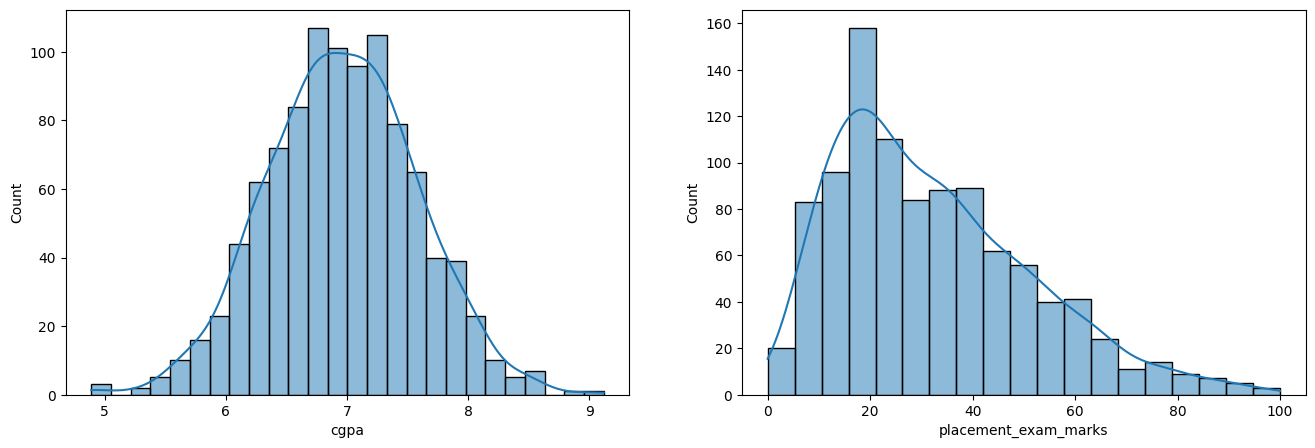

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.show()

#we can apply the z scor methode on cgpa not on marks as it is skewed and cgpa is normal

In [7]:
df['placement_exam_marks'].skew()


np.float64(0.8356419499466834)

In [8]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [9]:
'''
mean + 3*Std = upper
mean - 3*std = lower
'''
#finding the boundry 
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [10]:
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [11]:
#Trimming 

trim_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]

trim_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [12]:
'''
Z score = (value - mean) / std
'''
#Approach 2 Calculation of z score

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()


In [13]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [14]:
#we will not need values which are less than -3 amd greater than +3 Zscore

df[df['cgpa_zscore'] > 3]


,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [15]:
df[df['cgpa_zscore'] < -3]


,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [16]:
#Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)] 

In [17]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [18]:
#Capping : upper limit and lower Limit

upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

upper_limit, lower_limit


(np.float64(8.808933625397168), np.float64(5.113546374602832))

In [19]:
'''
if cgpa is more than upperlimit replace with upper limit and, 
if its lower than upper lint replace with lowerlimit
'''

df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

#np.where(x,y,z) x = condition  y = if true replace with  z = if false check this

In [20]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

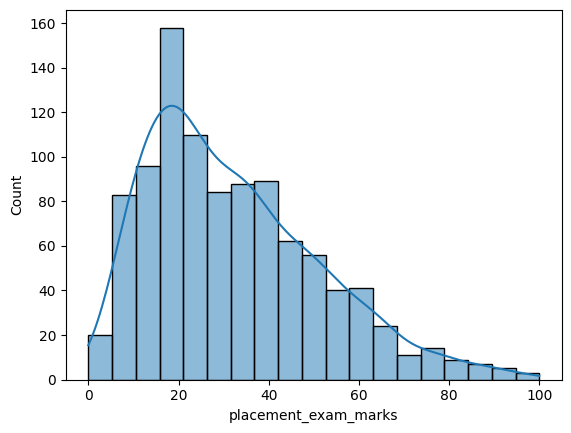

In [21]:
#now we will work with skewed data 
sns.histplot(df['placement_exam_marks'],kde=True)


In [22]:
df['placement_exam_marks'].describe

<bound method NDFrame.describe of 0      26.0
1      38.0
2      40.0
3       8.0
4      17.0
       ... 
995    44.0
996    65.0
997    34.0
998    46.0
999    10.0
Name: placement_exam_marks, Length: 1000, dtype: float64>

<Axes: ylabel='placement_exam_marks'>

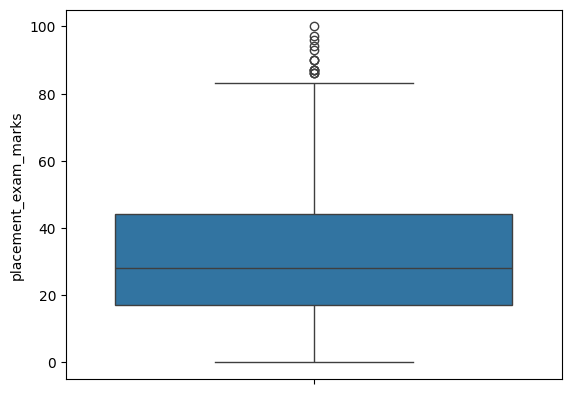

In [23]:
sns.boxplot(df['placement_exam_marks'])

In [24]:
#Finding IQR 
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

percentile25, percentile75


(np.float64(17.0), np.float64(44.0))

In [25]:
#Finding IQR 
iqr = percentile75 - percentile25

In [26]:
iqr 


np.float64(27.0)

In [27]:
upper = percentile75 + 1.5 * iqr
lower = percentile25 - 1.5 * iqr

print("Upper Limit(IQR):", upper)
print("lower Limit(IQR):", lower)



Upper Limit(IQR): 84.5
lower Limit(IQR): -23.5


In [28]:
df[df['placement_exam_marks'] > upper]

,cgpa,placement_exam_marks,placed,cgpa_zscore
9,7.75,94.0,1,1.280667
40,6.60,86.0,1,-0.586526
61,7.51,86.0,0,0.890992
134,6.33,93.0,0,-1.024910
162,7.80,90.0,0,1.361849
283,7.09,87.0,0,0.209061
290,8.38,87.0,0,2.303564
311,6.97,87.0,1,0.014223
324,6.64,90.0,0,-0.521580
630,6.56,96.0,1,-0.651472


In [29]:
df[df['placement_exam_marks'] < lower]
#no values cause right skewed

,cgpa,placement_exam_marks,placed,cgpa_zscore


In [30]:
#Trimming

new = df[df['placement_exam_marks'] < upper] 


In [31]:
new

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.190000,26.0,1,0.371425
1,7.460000,38.0,1,0.809810
2,7.540000,40.0,1,0.939701
3,6.420000,8.0,1,-0.878782
4,7.230000,17.0,0,0.436371
...,...,...,...,...
995,8.808934,44.0,1,3.099150
996,8.808934,65.0,1,3.505062
997,5.113546,34.0,0,-3.362960
998,8.620000,46.0,1,2.693239


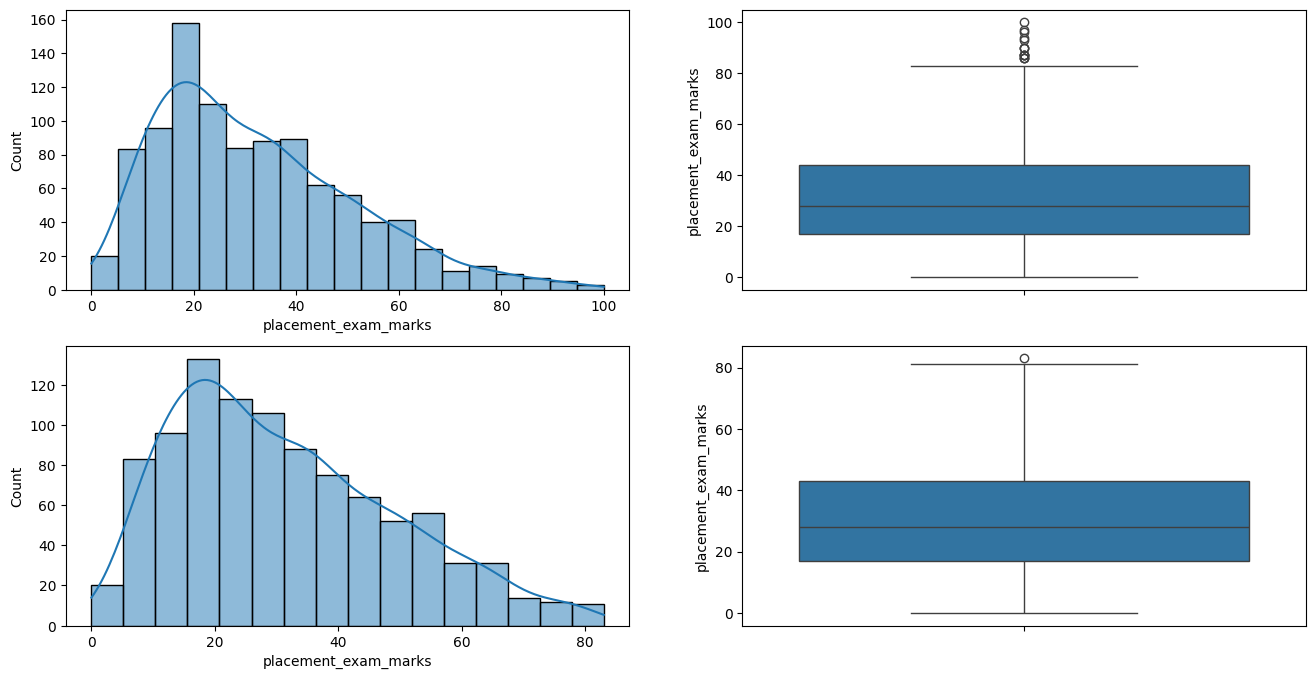

In [36]:

# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new['placement_exam_marks'], kde=True)

plt.subplot(2,2,4)
sns.boxplot(new['placement_exam_marks'])

plt.show()

In [33]:
#Or Capping can be Done 
new_df_copy = df.copy()

new_df_copy['placement_exam_marks'] = np.where(
    new_df_copy['placement_exam_marks'] > upper,
    upper,
    np.where(
        new_df_copy['placement_exam_marks'] < lower,
        lower,
        new_df_copy['placement_exam_marks']
    )
)


In [34]:
new_df_copy

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.190000,26.0,1,0.371425
1,7.460000,38.0,1,0.809810
2,7.540000,40.0,1,0.939701
3,6.420000,8.0,1,-0.878782
4,7.230000,17.0,0,0.436371
...,...,...,...,...
995,8.808934,44.0,1,3.099150
996,8.808934,65.0,1,3.505062
997,5.113546,34.0,0,-3.362960
998,8.620000,46.0,1,2.693239


In [35]:
new_df_copy.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.136500,0.489000,-1.465494e-16
std,0.612688,18.865419,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,84.500000,1.000000,3.505062e+00


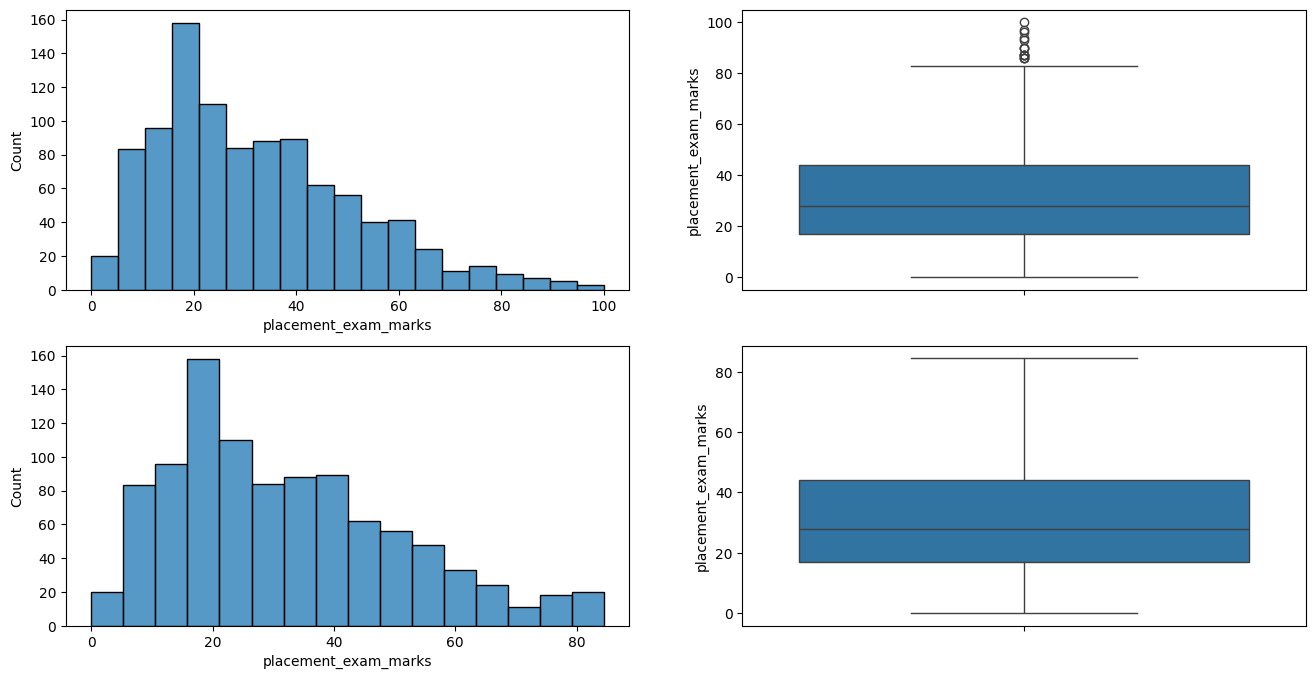

In [37]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_copy['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_copy['placement_exam_marks'])

plt.show()